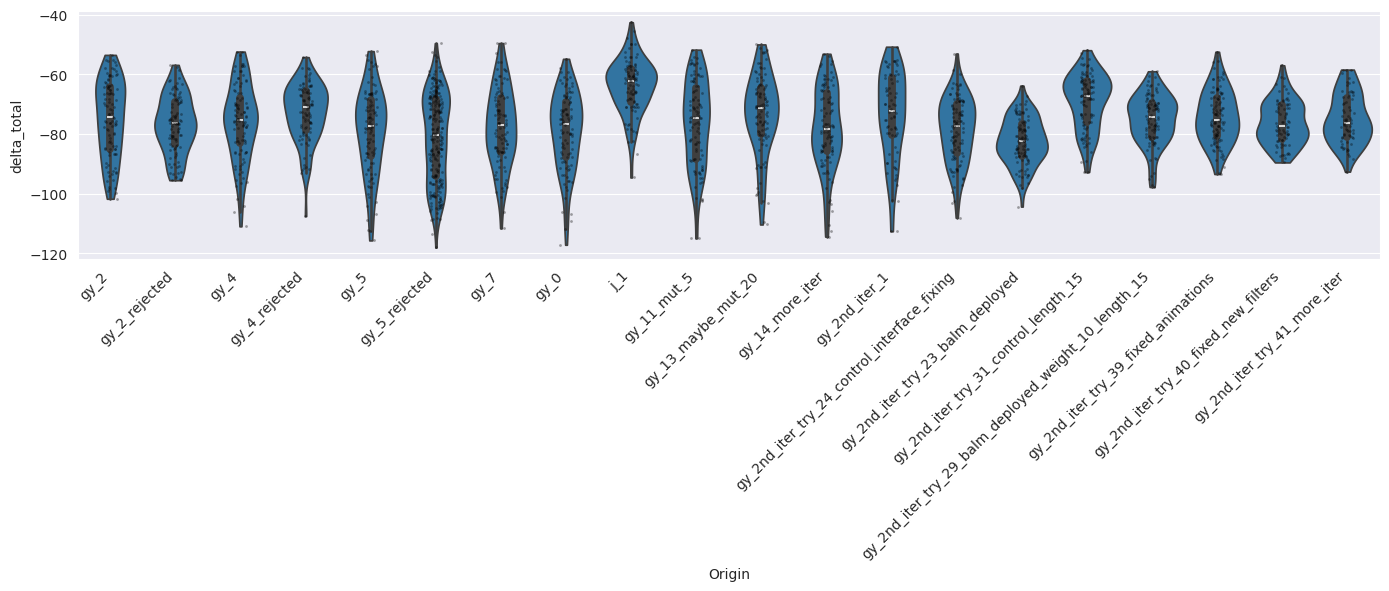

In [1]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

base = Path("/FastHome/gyula/designs/place_holder/DATA")

names = [
    "gy_2",
    "gy_2_rejected",
    "gy_4",
    "gy_4_rejected",
    "gy_5",
    "gy_5_rejected",
    "gy_7",
    "gy_0",
    "j_1",
    "gy_11_mut_5",
    "gy_13_maybe_mut_20",
    "gy_14_more_iter",
    "gy_2nd_iter_1",
    "gy_2nd_iter_try_24_control_interface_fixing",
    "gy_2nd_iter_try_23_balm_deployed",
    "gy_2nd_iter_try_31_control_length_15",
    "gy_2nd_iter_try_29_balm_deployed_weight_10_length_15",

    "gy_2nd_iter_try_39_fixed_animations",


    "gy_2nd_iter_try_40_fixed_new_filters",
    "gy_2nd_iter_try_41_more_iter"
]

frames = []
for name in names:
    csv_path = base / name / "md_sim_analysis" / "mmpbsa" / "jobs" / "delta_total_summary.csv"
    df = pd.read_csv(csv_path)
    df["origin"] = name
    frames.append(df)

all_df = pd.concat(frames, ignore_index=True)

outdir = Path("/FastHome/gyula/designs/place_holder/DATA/all_runs")
outdir.mkdir(exist_ok=True)

all_df.to_csv(outdir / "delta_total_concat.csv", index=False)
#all_df = all_df.loc[all_df.Length ==15,]
plt.figure(figsize=(14, 6))
sns.violinplot(data=all_df, x="origin", y="delta_total", inner="box", cut=0)
sns.stripplot(data=all_df, x="origin", y="delta_total", color="black", size=2, alpha=0.35)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Origin")
plt.ylabel("delta_total")
plt.tight_layout()
plt.show()
plt.close()

In [3]:
all_df.shape

(2096, 11)

In [12]:
all_df

,subdir,delta_total,dG_binding_IE,dG_binding_IE_err,origin
0,job_1,-55.38,-32.34,4.43,gy_2
1,job_10,-69.15,-27.49,6.78,gy_2
2,job_100,-55.96,-19.80,7.23,gy_2
3,job_101,-53.52,4.90,7.78,gy_2
4,job_102,-75.80,-57.83,6.75,gy_2
...,...,...,...,...,...
1635,job_95,-83.46,-57.57,7.16,gy_2nd_iter_try_23_balm_deployed
1636,job_96,-86.89,3.84,8.21,gy_2nd_iter_try_23_balm_deployed
1637,job_97,-85.27,-44.43,5.36,gy_2nd_iter_try_23_balm_deployed
1638,job_98,-82.51,-38.52,8.64,gy_2nd_iter_try_23_balm_deployed


rows: 103
all subdirs matched: True
all values equal: False
matching rows:     subdir  delta_total_gy_0_test  delta_total_gy_0  same_value
0  job_100                 -68.56            -71.62       False
1  job_101                 -63.21            -60.87       False
2  job_102                 -81.84            -80.06       False
3  job_103                -108.02            -87.94       False
4   job_10                 -55.83            -59.38       False


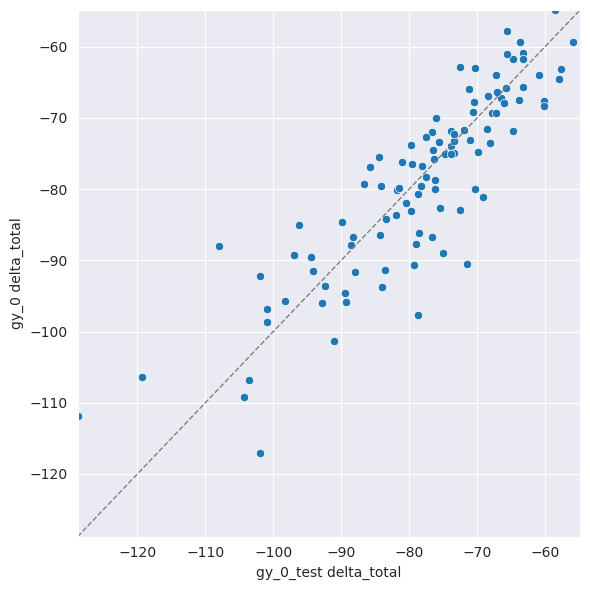

Spearman rho: 0.880832287748336
p-value: 1.4232767990351031e-34


In [13]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

base = Path("/FastHome/gyula/designs/place_holder/DATA")

def load_origin(origin):
    csv_path = base / origin / "md_sim_analysis" / "mmpbsa" / "jobs" / "delta_total_summary.csv"
    df = pd.read_csv(csv_path).copy()
    df["origin"] = origin
    return df

gy_0_test = load_origin("gy_0_test")
gy_0 = load_origin("gy_0")

merged = gy_0_test[["subdir", "delta_total"]].merge(
    gy_0[["subdir", "delta_total"]],
    on="subdir",
    suffixes=("_gy_0_test", "_gy_0"),
    validate="one_to_one"
)

merged["same_subdir"] = True
merged["same_value"] = merged["delta_total_gy_0_test"].eq(merged["delta_total_gy_0"])

print("rows:", len(merged))
print("all subdirs matched:", merged["same_subdir"].all())
print("all values equal:", merged["same_value"].all())
print("matching rows:", merged[["subdir", "delta_total_gy_0_test", "delta_total_gy_0", "same_value"]].head())

outdir = Path("output")
outdir.mkdir(exist_ok=True)
merged.to_csv(outdir / "gy_0_vs_gy_0_test_scatter_data.csv", index=False)

plt.figure(figsize=(6, 6))
sns.scatterplot(data=merged, x="delta_total_gy_0_test", y="delta_total_gy_0")
lims = [
    min(merged["delta_total_gy_0_test"].min(), merged["delta_total_gy_0"].min()),
    max(merged["delta_total_gy_0_test"].max(), merged["delta_total_gy_0"].max()),
]
plt.plot(lims, lims, "--", color="gray", linewidth=1)
plt.xlim(lims)
plt.ylim(lims)
plt.xlabel("gy_0_test delta_total")
plt.ylabel("gy_0 delta_total")
plt.tight_layout()
plt.show()
plt.close()

import numpy as np
from scipy.stats import spearmanr
rho, pval = spearmanr(merged["delta_total_gy_0_test"], merged["delta_total_gy_0"])
print("Spearman rho:", rho)
print("p-value:", pval)

In [16]:
merged

,subdir,delta_total_gy_0_test,delta_total_gy_0,same_subdir,same_value
0,job_100,-68.56,-71.62,True,False
1,job_101,-63.21,-60.87,True,False
2,job_102,-81.84,-80.06,True,False
3,job_103,-108.02,-87.94,True,False
4,job_10,-55.83,-59.38,True,False
...,...,...,...,...,...
98,job_96,-76.31,-75.80,True,False
99,job_97,-75.05,-88.99,True,False
100,job_98,-81.06,-76.19,True,False
101,job_99,-76.11,-69.97,True,False


In [14]:
gy_0_test

,subdir,delta_total,dG_binding_IE,dG_binding_IE_err,origin
0,job_100,-68.56,-3.87,8.33,gy_0_test
1,job_101,-63.21,-0.08,7.93,gy_0_test
2,job_102,-81.84,-39.40,9.64,gy_0_test
3,job_103,-108.02,-57.69,9.28,gy_0_test
4,job_10,-55.83,-7.72,10.77,gy_0_test
...,...,...,...,...,...
98,job_96,-76.31,-24.19,6.77,gy_0_test
99,job_97,-75.05,0.75,7.46,gy_0_test
100,job_98,-81.06,-44.21,10.20,gy_0_test
101,job_99,-76.11,-35.69,8.45,gy_0_test


In [15]:
all_df

,subdir,delta_total,dG_binding_IE,dG_binding_IE_err,origin
0,job_1,-55.38,-32.34,4.43,gy_2
1,job_10,-69.15,-27.49,6.78,gy_2
2,job_100,-55.96,-19.80,7.23,gy_2
3,job_101,-53.52,4.90,7.78,gy_2
4,job_102,-75.80,-57.83,6.75,gy_2
...,...,...,...,...,...
1635,job_95,-83.46,-57.57,7.16,gy_2nd_iter_try_23_balm_deployed
1636,job_96,-86.89,3.84,8.21,gy_2nd_iter_try_23_balm_deployed
1637,job_97,-85.27,-44.43,5.36,gy_2nd_iter_try_23_balm_deployed
1638,job_98,-82.51,-38.52,8.64,gy_2nd_iter_try_23_balm_deployed
